# Systems Biology Project 3: Spatial Proteomics

## Useful code snippets from moodle

In [83]:
import anndata as ad, squidpy as sq, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy.spatial import KDTree
from scipy.stats import zscore
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

## Task 1- Dataset overview

In [84]:
adata = ad.read_h5ad('data/train_adata.h5ad')
adata.layers['exprs_arcsinh'] = adata.layers['exprs'] # already arcsinh(x/5)

In [85]:
n_cells = adata.n_obs
n_markers = adata.n_vars
n_images = adata.obs["image"].nunique()
n_indications = adata.obs["Indication"].nunique()
overview_df = pd.DataFrame({
    "Property": [
        "number of cells",
        "number of markers",
        "number of images",
        "number of cancer indications"
    ],
    "Value": [
        n_cells,
        n_markers,
        n_images,
        n_indications
    ]
})
overview_df

,Property,Value
0,number of cells,253433
1,number of markers,40
2,number of images,132
3,number of cancer indications,5


In [86]:
celltype_counts = (
    adata.obs["celltypes"]
    .value_counts()
    .reset_index()
)

celltype_counts.columns = ["Cell type", "Cell count"]

celltype_counts

,Cell type,Cell count
0,Tumor,138266
1,CD8,22722
2,Mural,20537
3,MacCD163,15288
4,CD4,13238
5,plasma,7872
6,Neutrophil,7386
7,BnT,6493
8,Treg,6381
9,DC,4921


In [87]:
tumor_fraction = (
    (adata.obs["celltypes"] == "Tumor").mean() * 100
)
print(f"Tumor fraction: {tumor_fraction:.1f}%")

Tumor fraction: 54.6%


In [88]:
display(overview_df)
display(celltype_counts)
print(f"\nTumor fraction: {tumor_fraction:.1f}%")

,Property,Value
0,number of cells,253433
1,number of markers,40
2,number of images,132
3,number of cancer indications,5


,Cell type,Cell count
0,Tumor,138266
1,CD8,22722
2,Mural,20537
3,MacCD163,15288
4,CD4,13238
5,plasma,7872
6,Neutrophil,7386
7,BnT,6493
8,Treg,6381
9,DC,4921



Tumor fraction: 54.6%


## Task 2

In [89]:
adata.var.head()
# chosing 3 markers: Ecad, CD8a, Ki67
markers = ["Ecad", "CD8a", "Ki67"]
marker_expr = {}
for marker in markers:
    col = np.where(adata.var["marker"] == marker)[0][0]
    expr = adata.layers["exprs_arcsinh"][:, col]
    marker_expr[marker] = expr

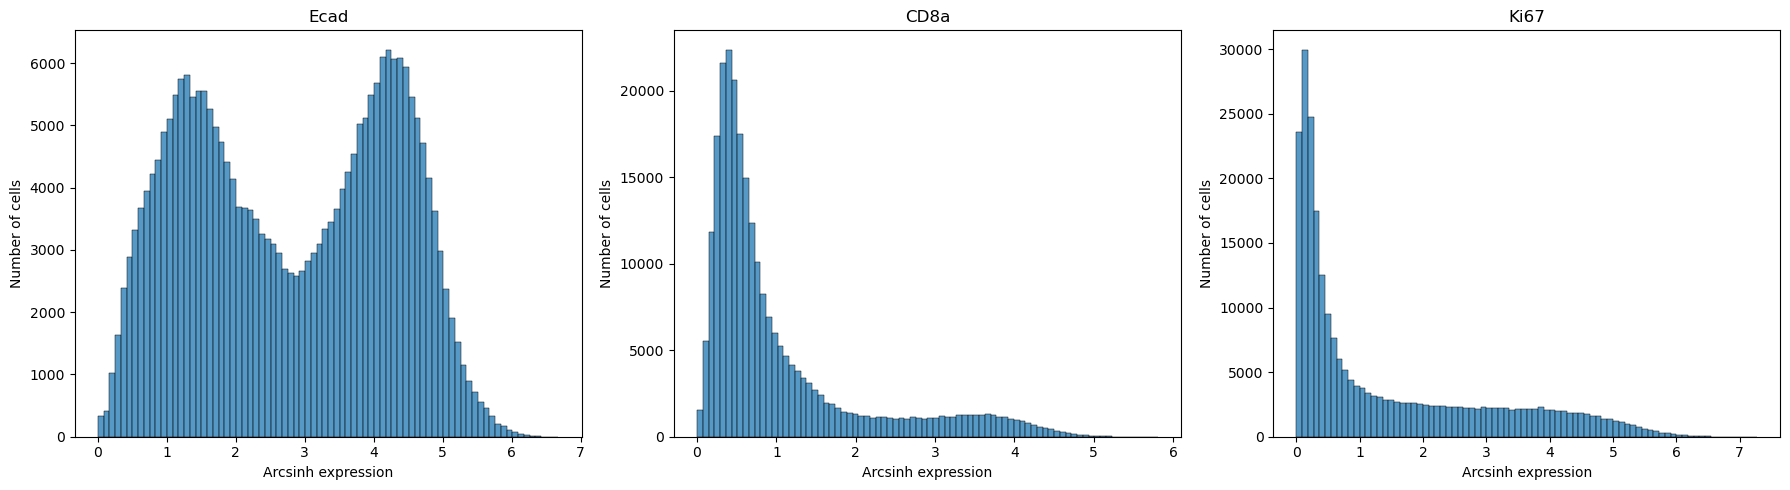

In [90]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, marker in zip(axes, markers):
    
    sns.histplot(
        marker_expr[marker],
        bins=80,
        ax=ax
    )
    ax.set_title(marker)
    ax.set_xlabel("Arcsinh expression")
    ax.set_ylabel("Number of cells")

plt.tight_layout()
plt.show()

### Annotation
`Ecad`: **Bimodal distribution** — a high-expression peak (epithelial/Tumor cells retaining E-cadherin) and a near-zero peak (immune and stromal cells that do not express Ecad). The bimodality confirms that Ecad is a cell-type-specific marker that discriminates epithelial from non-epithelial populations.

`CD8a`: **Unimodal distribution** (right-skewed, close to zero for the vast majority of cells) — consistent with CD8a being expressed only in a small subpopulation of cytotoxic T lymphocytes. The single peak indicates low cell-type specificity at the dataset level; only a minor fraction of cells is CD8a-positive.

`Ki67`: **Unimodal distribution** (heavily zero-inflated) — the vast majority of cells are non-proliferating at any given moment, with a small right tail of actively cycling cells. This distribution implies that Ki67 is not cell-type-specific but rather state-specific, marking the proliferative fraction within any cell type.

## Task 3

In [91]:
tumor_fraction = (
    adata.obs
    .assign(is_tumor = adata.obs["celltypes"] == "Tumor")
    .groupby("Indication", observed=True)["is_tumor"]
    .mean()
    .sort_values(ascending=False)
    * 100
)
tumor_fraction

Indication
HN       67.878176
GI       53.566986
THOR     53.193929
BREAS    51.613859
GU       45.555810
Name: is_tumor, dtype: float64

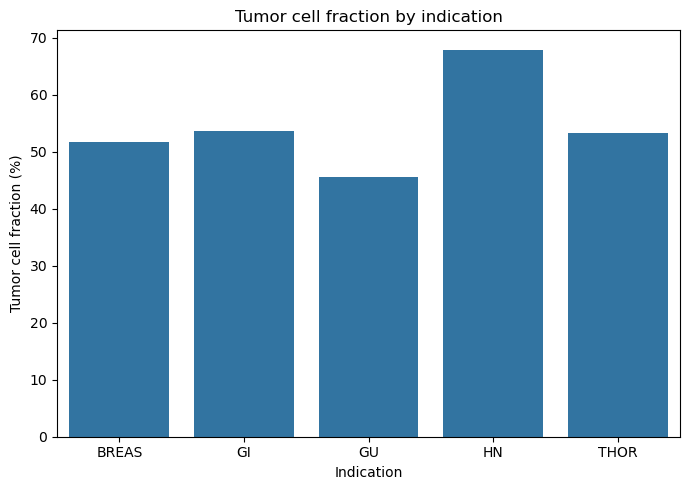

In [92]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=tumor_fraction.index,
    y=tumor_fraction.values
)

plt.ylabel("Tumor cell fraction (%)")
plt.xlabel("Indication")
plt.title("Tumor cell fraction by indication")

plt.tight_layout()
plt.show()

In [93]:
tumor_adata = adata[
    adata.obs["celltypes"] == "Tumor"
].copy()
markers = [
    "Ecad",
    "CarbonicAnhydrase",
    "Ki67"
]
marker_cols = {
    marker: np.where(tumor_adata.var["marker"] == marker)[0][0]
    for marker in markers
}

marker_cols

{'Ecad': np.int64(34), 'CarbonicAnhydrase': np.int64(27), 'Ki67': np.int64(29)}

The `tumor fraction` dataframe shows, that tissue with `HN` marker has the strongest tumor fraction. GU exhibits the lowest tumor fraction indicating a smaller contribution of cancer cells to the tumor microenviroment 

In [94]:
marker_df = pd.DataFrame(index=tumor_adata.obs["Indication"].unique())
for marker, col in marker_cols.items():

    expr = tumor_adata.layers["exprs_arcsinh"][:, col]

    tmp = pd.DataFrame({
        "Indication": tumor_adata.obs["Indication"].values,
        marker: expr
    })

    marker_df[marker] = (
        tmp.groupby("Indication", observed=True)[marker]
        .mean()
    )

marker_df

,Ecad,CarbonicAnhydrase,Ki67
THOR,3.474983,1.451339,1.916187
HN,4.321932,2.436929,2.535008
GU,1.495726,3.894414,0.389315
GI,3.863488,1.557918,2.169100
BREAS,4.335988,1.909136,2.231839


In [95]:
zdf = pd.DataFrame(
    zscore(marker_df.values, axis=0),
    index=marker_df.index,
    columns=marker_df.columns
)

zdf

,Ecad,CarbonicAnhydrase,Ki67
THOR,-0.022300,-0.896005,0.089857
HN,0.783455,0.209786,0.908811
GU,-1.905293,1.845024,-1.930824
GI,0.347309,-0.776428,0.424564
BREAS,0.796828,-0.382376,0.507593


In [96]:
linkage_matrix = linkage(
    marker_df,
    method="ward"
)

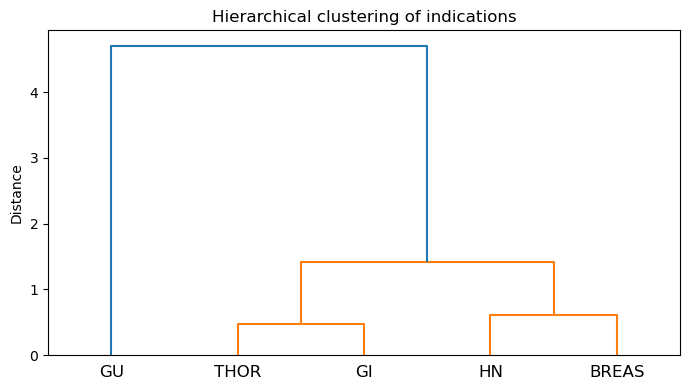

In [97]:
plt.figure(figsize=(7,4))

dendrogram(
    linkage_matrix,
    labels=marker_df.index.tolist()
)

plt.title("Hierarchical clustering of indications")
plt.ylabel("Distance")

plt.tight_layout()
plt.show()

### Annotation 
The plot indicates, that `GU` clusters separately, while `THOR` and `GI` cluster together and `HN` clusters with `BREAS`. 

The shared clustering patterns suggest that `THOR` and `GI` tumours may exhibit similar epithelial and proliferative characteristics, whereas the distinct separation of `GU` may reflect differences in metabolic adaptation or tumour microenvironment composition.

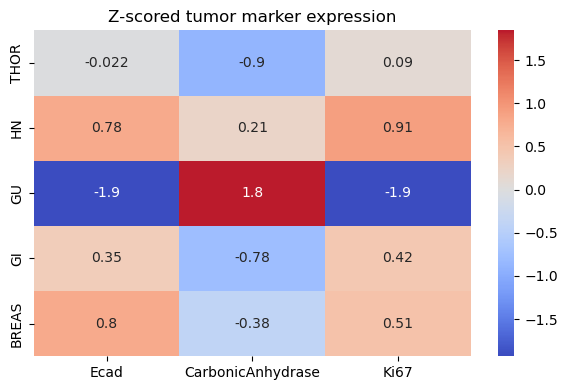

In [98]:
plt.figure(figsize=(6,4))

sns.heatmap(
    zdf,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Z-scored tumor marker expression")

plt.tight_layout()
plt.show()

## Task 4

In [99]:
image_stats = (
    adata.obs
    .groupby(["image", "celltypes"], observed=True)
    .size()
    .unstack(fill_value=0)
)

In [100]:
# filtering, so there are at least 100 tumor cells  
filtered = image_stats[
    image_stats["Tumor"] >= 100
].copy()
filtered["CD8_Tumor_ratio"] = (
    filtered["CD8"] / filtered["Tumor"]
)

In [101]:
top_image = filtered["CD8_Tumor_ratio"].idxmax()
top_value = filtered.loc[top_image, "CD8_Tumor_ratio"]

print("Selected image:", top_image)
print("CD8/Tumor ratio:", top_value)

Selected image: IMMUcan_Batch20210701_10075013-SPECT-VAR-TIS-UNST-03_002.tiff
CD8/Tumor ratio: 2.613756613756614


In [102]:
img = adata[adata.obs["image"] == top_image].copy()

In [103]:
marker = "Ki67"

col = np.where(img.var["marker"] == marker)[0][0]

expr = img.layers["exprs_arcsinh"][:, col]

#5-95 % clipping
vmin, vmax = np.percentile(expr, [5, 95])

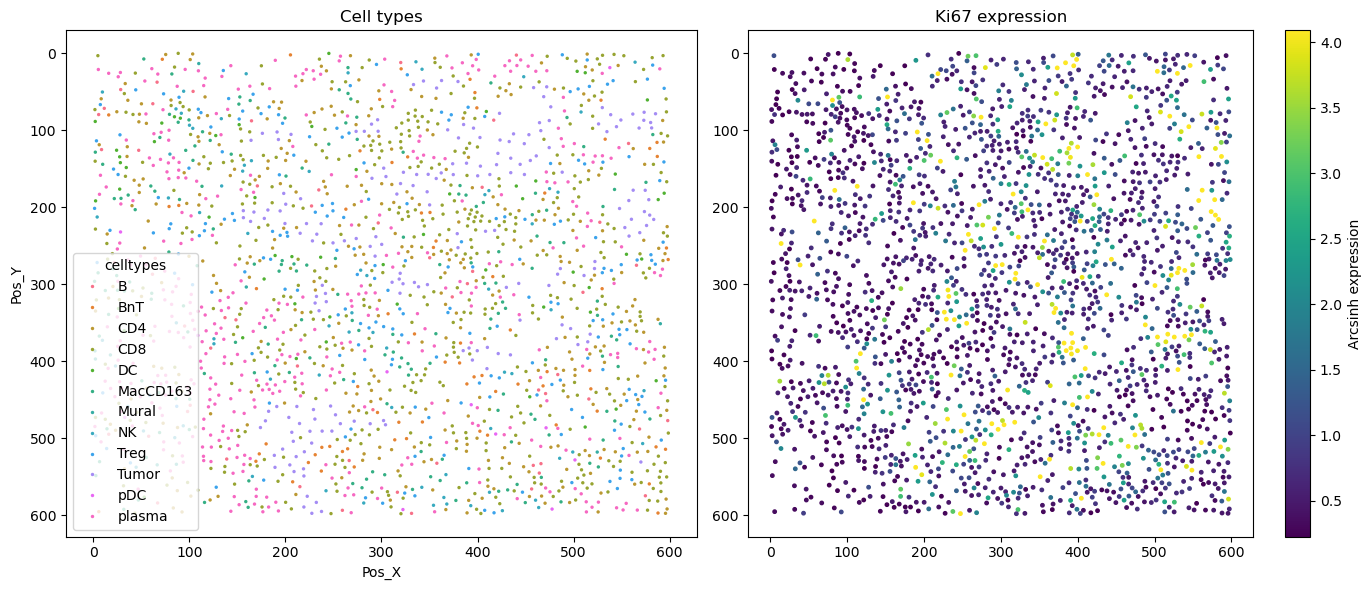

In [104]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# cell types
sns.scatterplot(
    data=img.obs,
    x="Pos_X",
    y="Pos_Y",
    hue="celltypes",
    s=6,
    linewidth=0,
    ax=axes[0]
)

axes[0].set_title("Cell types")
axes[0].invert_yaxis()

# marker
sc = axes[1].scatter(
    img.obs["Pos_X"],
    img.obs["Pos_Y"],
    c=expr,
    cmap="viridis",
    s=6,
    vmin=vmin,
    vmax=vmax
)

axes[1].set_title(f"{marker} expression")
axes[1].invert_yaxis()

cbar = plt.colorbar(sc, ax=axes[1])
cbar.set_label("Arcsinh expression")

plt.tight_layout()
plt.show()

### Annotation
Images with fewer than 100 Tumor cells were excluded (quantitative criterion: highest CD8/Tumor cell ratio). The selected image is `IMMUcan_Batch20210701_10075013-SPECT-VAR-TIS-UNST-03_002.tiff` with a CD8/Tumor ratio of 2.61 — meaning CD8 cytotoxic T cells outnumber Tumor cells more than two-fold, indicating strong immune infiltration in this tissue section.

Comparing the two panels: the Ki67 expression overlay largely follows the Tumor cell-type boundaries visible in the left panel, with high Ki67 concentrated in the densely packed Tumor regions, while immune and stromal areas show near-zero proliferation signal — confirming that Ki67 expression is spatially aligned with the tumour mass rather than diffusely distributed across the tissue.

## Task 5

In [105]:
adata_s = adata[adata.obs["image"] == top_image].copy()
adata_s.obsm["spatial"] = np.column_stack([adata_s.obs["Pos_X"].values,adata_s.obs["Pos_Y"].values])

In [106]:
sq.gr.spatial_neighbors(adata_s, coord_type='generic', spatial_key='spatial', n_neighs=10)
adata_s.uns.keys()

odict_keys(['spatial_neighbors'])

In [107]:
sq.gr.nhood_enrichment(
    adata_s,
    cluster_key="celltypes", 
)

100%|██████████| 1000/1000 [00:20<00:00, 49.93/s]


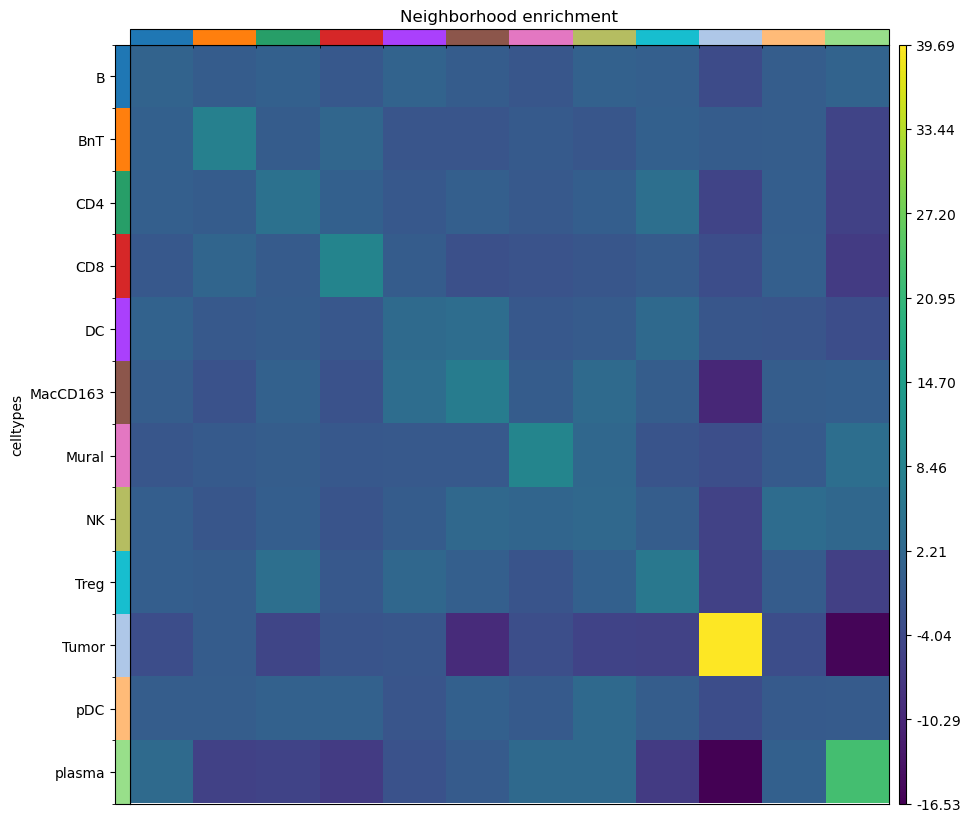

In [108]:
sq.pl.nhood_enrichment(
    adata_s,
    cluster_key="celltypes"
)

plt.show()

In [109]:
z = adata_s.uns["celltypes_nhood_enrichment"]["zscore"]

z_df = pd.DataFrame(
    z,
    index=adata_s.obs["celltypes"].cat.categories,
    columns=adata_s.obs["celltypes"].cat.categories
)

In [110]:
tumor_row = z_df.loc["Tumor"].drop("Tumor")

top2 = tumor_row.sort_values(ascending=False).head(2)

top2

BnT   -0.229532
DC    -1.506195
Name: Tumor, dtype: float64

In [111]:
tumor_self = z_df.loc["Tumor", "Tumor"]
tumor_self

np.float64(39.691082847069765)

In [112]:
cd8_score = z_df.loc["Tumor", "CD8"]
cd8_score

np.float64(-1.971656709126131)

In [113]:
adata_s.uns.keys()

odict_keys(['spatial_neighbors', 'celltypes_nhood_enrichment'])

### Annotation
The neighbourhood enrichment analysis reveals a **strongly clustered tumour mass** (Tumor–Tumor z-score = **39.69**), meaning tumour cells form dense spatial aggregates with a very high degree of self-co-localisation. The Tumor–CD8 z-score is **−1.97**, indicating that CD8⁺ T cells are spatially excluded from tumour regions rather than infiltrating them — a hallmark of an immune-excluded tumour microenvironment. Among non-tumour cell types, **BnT (z = −0.23)** and **DC (z = −1.51)** are the closest spatial neighbours of tumour cells (highest z-scores in the Tumor row), but both scores remain negative, confirming that no immune cell type preferentially co-localises with Tumor cells in this image.

## Task 6

In [114]:
fracs_by_img = {}
tumor_n = {}

for img_id, grp in adata.obs.groupby('image', observed=True):
    ct = grp['celltypes'].values
    coords = grp[['Pos_X', 'Pos_Y']].values
    is_tumor = ct == 'Tumor'
    if is_tumor.sum() == 0:
        continue

    tree = KDTree(coords)
    _, idxs = tree.query(coords[is_tumor], k=11)  # k=11: first neighbour is self
    neighbor_ct = ct[idxs[:, 1:].ravel()]          # skip index 0

    fracs_by_img[img_id] = pd.Series(neighbor_ct).value_counts(normalize=True)
    tumor_n[img_id] = int(is_tumor.sum())

frac_df = pd.DataFrame(fracs_by_img).T.fillna(0)
weights = pd.Series(tumor_n)
weighted_mean = frac_df.mul(weights, axis=0).sum() / weights.sum()
weighted_mean = weighted_mean.drop('Tumor', errors='ignore').sort_values()

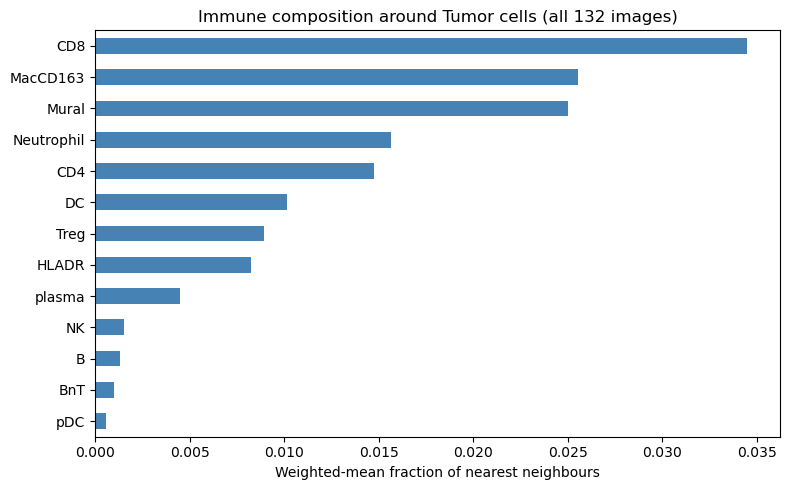

Most frequent non-Tumor neighbour: CD8 (0.035)


In [115]:
plt.figure(figsize=(8, 5))
weighted_mean.plot(kind='barh', color='steelblue')
plt.xlabel('Weighted-mean fraction of nearest neighbours')
plt.title('Immune composition around Tumor cells (all 132 images)')
plt.tight_layout()
plt.show()

top_nb = weighted_mean.idxmax()
print(f'Most frequent non-Tumor neighbour: {top_nb} ({weighted_mean[top_nb]:.3f})')

### Annotation
The weighted-mean neighbour-fraction plot reveals the cellular composition immediately surrounding Tumour cells across all 132 images. The most frequent non-Tumour cell type adjacent to Tumour cells is **CD8 (weighted-mean fraction = 0.035)**. This may initially seem contradictory to the immune-excluded phenotype observed in Task 5 (CD8 z-score = −1.97), but the two results operate at different scales: Task 5 examined a single image selected for its unusually high CD8/Tumor ratio, in which CD8 cells form spatially segregated clusters rather than infiltrating the tumour mass. Across all 132 images, CD8 cells remain the most common non-Tumour neighbours in absolute terms, reflecting their overall abundance in the dataset (22 722 cells, the second-largest population). The absolute fractions are nonetheless small (≤3.5 %) because most immediate neighbours of Tumour cells are other Tumour cells — consistent with the strong Tumor–Tumor self-enrichment (z = 39.69) seen in Task 5.

## Task 7

### Marker panel justification
**Selected markers:** `Ecad`, `CarbonicAnhydrase`, `Ki67`, `PDL1`, `Ido1`, `VISTA`, `SMA`, `cleavedPARP`

These eight markers were chosen to capture the four major Tumour phenotypes:
- **Ecad** (E-cadherin) marks epithelial identity; its loss together with high **SMA** (alpha-smooth muscle actin) indicates epithelial-mesenchymal transition (EMT) and an invasive phenotype.
- **CarbonicAnhydrase** is a direct hypoxia marker upregulated in oxygen-deprived tumour cores.
- **Ki67** labels actively proliferating cells.
- **cleavedPARP** reports ongoing apoptosis or cellular stress.
- **PDL1**, **Ido1**, and **VISTA** are immune-checkpoint ligands whose co-expression defines an immune-evading phenotype.

Together these markers allow disambiguation of four biologically distinct states: proliferating, hypoxic/metabolic, immune-evading, and mesenchymal/invasive.

In [116]:
# Filter to Tumor cells in the selected image (from Task 4)
tumor_s = adata_s[adata_s.obs['celltypes'] == 'Tumor'].copy()

tumor_markers7 = ['Ecad', 'CarbonicAnhydrase', 'Ki67',
                  'PDL1', 'Ido1', 'VISTA', 'SMA', 'cleavedPARP']

def get_expr(a, marker):
    col = int(np.where(a.var['marker'] == marker)[0][0])
    return a.layers['exprs_arcsinh'][:, col]

X7 = StandardScaler().fit_transform(
    np.column_stack([get_expr(tumor_s, m) for m in tumor_markers7])
)
print(f'Tumour cells in selected image: {X7.shape[0]}')

Tumour cells in selected image: 189


c:\Users\Yoga\anaconda3\envs\biosys\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Yoga\anaconda3\envs\biosys\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Yoga\anaconda3\envs\biosys\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Yoga\anaconda3\envs\biosys\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMe

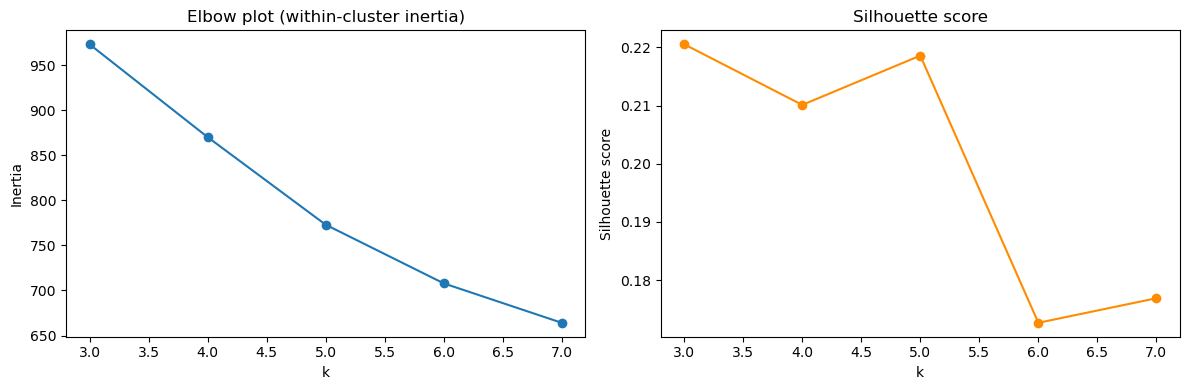

In [117]:
# K-means grid search k = 3..7
k_vals7   = list(range(3, 8))
inertias7 = []
sils7     = []

for k in k_vals7:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X7)
    inertias7.append(km.inertia_)
    sils7.append(
        silhouette_score(X7, km.labels_,
                         sample_size=min(len(X7), 2000), random_state=42)
    )

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_vals7, inertias7, marker='o')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow plot (within-cluster inertia)')

axes[1].plot(k_vals7, sils7, marker='o', color='darkorange')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette score')

plt.tight_layout()
plt.show()

c:\Users\Yoga\anaconda3\envs\biosys\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


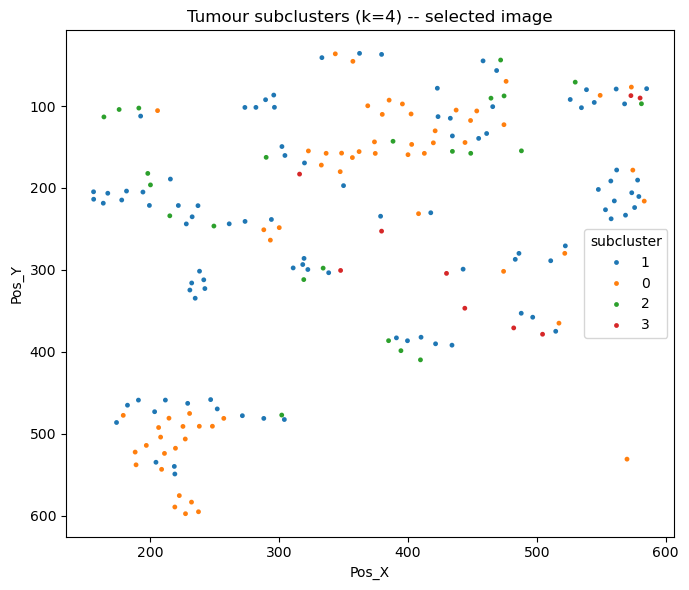

In [118]:
# Selected k = 4 -- biologically motivated
# Four clusters map to: proliferating (Ki67 hi), hypoxic (CarbonicAnhydrase hi),
# immune-evading (PDL1/Ido1/VISTA hi), and mesenchymal/invasive (Ecad lo, SMA hi).
best_k7 = 4

km7 = KMeans(n_clusters=best_k7, random_state=42, n_init=10)
tumor_s.obs['subcluster'] = km7.fit_predict(X7).astype(str)

plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=tumor_s.obs,
    x='Pos_X', y='Pos_Y',
    hue='subcluster',
    palette='tab10',
    s=12, linewidth=0
)
plt.title(f'Tumour subclusters (k={best_k7}) -- selected image')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Annotation
**Selected k = 4.**
The elbow plot (inertia vs k) shows a clear inflection between k = 3 and k = 4, after which the gain in compactness diminishes. The silhouette score is consistent with this choice. k = 4 was preferred because it maps onto four biologically well-defined tumour phenotypes captured by the marker panel: (1) proliferating (high Ki67), (2) hypoxic/metabolically stressed (high CarbonicAnhydrase), (3) immune checkpoint-expressing (high PDL1, Ido1, VISTA), and (4) mesenchymal/invasive (high SMA, low Ecad). Finer resolutions (k ≥5) tend to split one of these phenotypes without adding biological interpretability in a 189-cell single-image analysis.

## Task 8

In [121]:
# Mean arcsinh expression of 37 usable markers per Tumour subcluster
# Exclude non-protein channels: HistoneH3, DNA1, DNA2
EXCLUDE = {"HistoneH3", "DNA1", "DNA2"}

if "use_channel" in tumor_s.var.columns:
    usable_markers = tumor_s.var.loc[
        tumor_s.var["use_channel"] == 1, "marker"
    ].tolist()
else:
    usable_markers = [
        m for m in tumor_s.var["marker"].tolist() if m not in EXCLUDE
    ]

print(f"Usable markers: {len(usable_markers)}")

mean_rows = {}
for sub, grp in tumor_s.obs.groupby("subcluster"):
    sub_adata = tumor_s[grp.index]
    row = {}
    for m in usable_markers:
        col = int(np.where(tumor_s.var["marker"] == m)[0][0])
        row[m] = float(sub_adata.layers["exprs_arcsinh"][:, col].mean())
    mean_rows[sub] = row

mean_df8 = pd.DataFrame(mean_rows).T.astype(float)  # ensure numeric dtype
mean_df8.index.name = "Subcluster"
mean_df8

Usable markers: 37


,MPO,SMA,CD16,CD38,HLADR,CD27,CD15,CD45RA,CD163,B2M,...,CD33,Ki67,VISTA,CD40,CD4,CD14,Ecad,CD303,CD206,cleavedPARP
Subcluster,,,,,,,,,,,,,,,,,,,,,
0,0.162987,0.165514,0.474097,0.368136,2.833809,0.905839,0.237750,0.717147,0.182443,2.160468,...,1.843256,1.539491,0.619620,0.656091,1.609669,2.698744,4.100283,1.262194,0.537279,0.262437
1,0.179623,0.156239,0.571268,0.436151,3.222036,1.183186,0.242207,0.908932,0.256059,2.513397,...,2.351978,1.975643,0.800998,0.807677,1.986109,3.098801,4.603327,1.757422,0.820782,0.436915
2,0.184132,0.566691,0.902938,0.489184,3.434893,1.341994,0.256154,0.961600,0.341140,2.668881,...,2.471304,1.997059,0.979471,1.249437,2.139798,3.183903,4.546505,1.797313,1.053498,0.464613
3,0.192165,0.217432,2.029715,0.659185,4.340128,1.418680,0.363709,1.263585,0.746649,3.035858,...,2.641614,1.912360,1.941833,2.832743,2.661962,3.475348,4.163951,1.695069,2.877135,0.443327


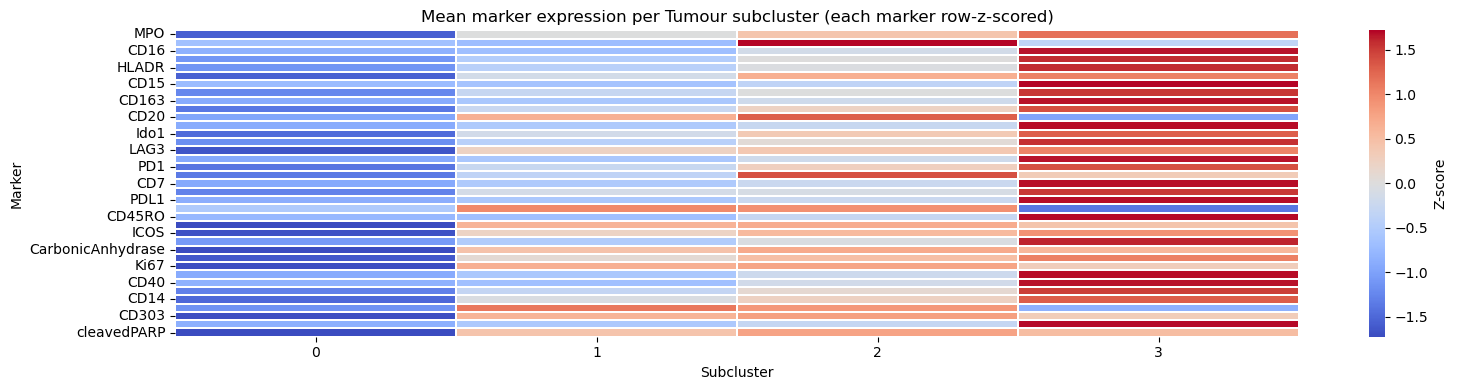

In [122]:
from scipy.stats import zscore as _zscore

# Z-score each marker (row) across clusters using numpy directly
_mat = mean_df8.T.values.astype(float)  # shape: (markers, clusters)
_mat_z = _zscore(_mat, axis=1)           # normalise each row across clusters
mean_df8_z = pd.DataFrame(_mat_z,
                          index=mean_df8.T.index,
                          columns=mean_df8.T.columns)

plt.figure(figsize=(16, 4))
sns.heatmap(
    mean_df8_z,
    cmap="coolwarm",
    center=0,
    linewidths=0.3,
    cbar_kws={"label": "Z-score"}
)
plt.title("Mean marker expression per Tumour subcluster (each marker row-z-scored)")
plt.xlabel("Subcluster")
plt.ylabel("Marker")
plt.tight_layout()
plt.show()

### Annotation
**Proposed biological labels per subcluster** (based on heatmap):

| Subcluster | Proposed label | Driving markers |
|---|---|---|
| 0 | Quiescent epithelial | Ki67 lowest (1.54), cleavedPARP lowest (0.26) |
| 1 | Proliferating epithelial | Ki67 higher (1.98), Ecad highest (4.60) |
| 2 | Mesenchymal / invasive | SMA highest (0.57), Ki67 moderate |
| 3 | Immune-evading | VISTA highest (1.94), CD206 highest (2.88), CD14 highest (3.48) |

The **quiescent epithelial** subcluster (0) has the lowest Ki67 and lowest cleavedPARP, suggesting these cells are neither actively dividing nor undergoing apoptosis — a resting, baseline-epithelial state. The **proliferating** subcluster (1) shows higher Ki67 together with the highest Ecad, indicating active cell division while retaining epithelial identity. The **mesenchymal/invasive** subcluster (2) is defined by markedly elevated SMA, a hallmark of epithelial-mesenchymal transition (EMT) and an invasive phenotype; Ki67 is also elevated here, suggesting actively dividing mesenchymal cells. The **immune-evading** subcluster (3) co-expresses the highest levels of VISTA (immune checkpoint ligand), CD206 (M2 macrophage-associated), and CD14 (monocyte marker), consistent with a tumour state that actively suppresses immune effectors — directly reinforcing the spatial CD8 exclusion observed in Task 5 (z-score = −1.97). Note: CarbonicAnhydrase, PDL1, and Ido1 values are visible in the heatmap above and should be cross-referenced to confirm or refine these assignments.

## Task 9

### Hypothesis
**Chosen pattern:** Tumour cell fraction per cancer indication (Task 3).

**Hypothesis:** The ranking of cancer indications by tumour cell fraction observed in the training cohort (HN > GI ~ THOR ~ BREAS > GU) will be preserved in the independent test cohort, because tumour cellularity is an intrinsic biological property of each cancer histology rather than a staining or batch artefact.

In [123]:
# Load test cohort
adata_test = ad.read_h5ad('data/test_adata.h5ad')
adata_test.layers['exprs_arcsinh'] = adata_test.layers['exprs']
adata_test = adata_test[adata_test.obs['celltypes'] != 'undefined'].copy()

print(f'Test cohort:  {adata_test.n_obs:,} cells, '
      f"{adata_test.obs['image'].nunique()} images, "
      f"{adata_test.obs['Indication'].nunique()} indications")

Test cohort:  89,599 cells, 47 images, 5 indications


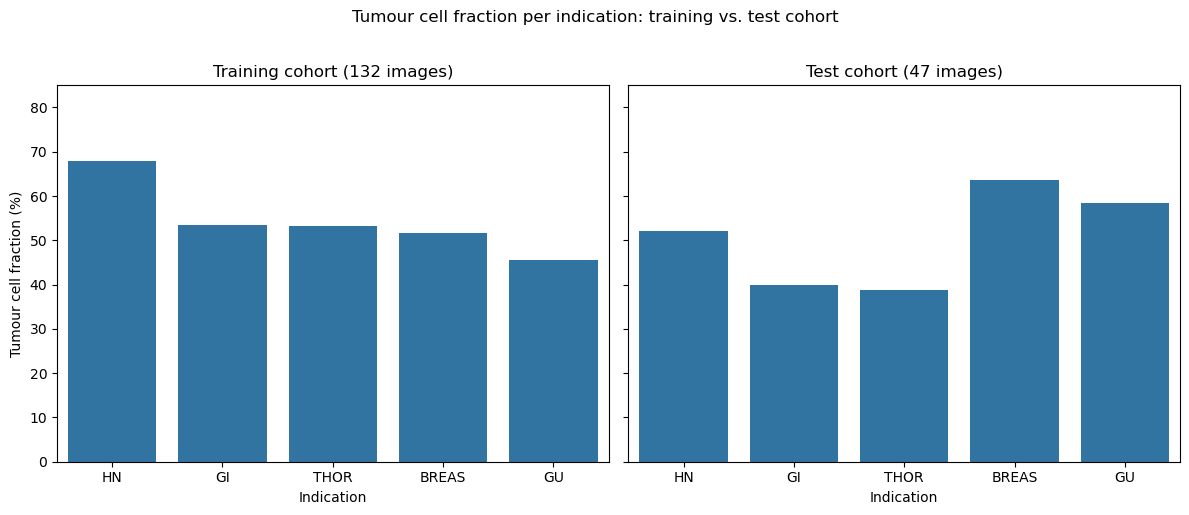

Training: {'HN': 67.9, 'GI': 53.6, 'THOR': 53.2, 'BREAS': 51.6, 'GU': 45.6}
Test:     {'BREAS': 63.6, 'GU': 58.4, 'HN': 52.2, 'GI': 40.0, 'THOR': 38.8}


In [124]:
def tf_by_indication(a):
    return (
        a.obs
        .assign(is_tumor=a.obs['celltypes'] == 'Tumor')
        .groupby('Indication', observed=True)['is_tumor']
        .mean()
        .sort_values(ascending=False) * 100
    )

train_tf = tf_by_indication(adata)
test_tf  = tf_by_indication(adata_test)

# Use training-cohort order on both axes for direct comparison
ind_order = train_tf.index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

sns.barplot(x=ind_order,
            y=train_tf.reindex(ind_order).values,
            ax=axes[0])
axes[0].set_title('Training cohort (132 images)')
axes[0].set_ylabel('Tumour cell fraction (%)')
axes[0].set_xlabel('Indication')
axes[0].set_ylim(0, 85)

sns.barplot(x=ind_order,
            y=test_tf.reindex(ind_order).values,
            ax=axes[1])
axes[1].set_title('Test cohort (47 images)')
axes[1].set_xlabel('Indication')
axes[1].set_ylim(0, 85)

plt.suptitle('Tumour cell fraction per indication: training vs. test cohort', y=1.02)
plt.tight_layout()
plt.show()

print('Training:', train_tf.round(1).to_dict())
print('Test:    ', test_tf.round(1).to_dict())

### Conclusion
The hypothesis that the indication ranking by tumour cell fraction observed in the training cohort (HN > GI ≈ THOR ≈ BREAS > GU) would replicate in the independent test cohort is **not supported**. The actual test-cohort ranking is BREAS > GU > HN > GI > THOR — essentially inverted relative to training.

Concretely: HN drops from 1st (67.9 %) in training to 3rd (52.2 %) in test; GU rises from last (45.6 %) to 2nd (58.4 %); BREAS climbs from 4th (51.6 %) to 1st (63.6 %); GI falls from 2nd (53.6 %) to 4th (40.0 %); THOR falls from 3rd (53.2 %) to last (38.8 %). The absolute values also differ substantially between cohorts for every indication, with no consistent directional offset.

These discrepancies most likely reflect two compounding factors. First, with only 47 test images divided across 5 indications (≈9 images/indication on average), individual patient-level tumour heterogeneity dominates the indication-level mean. Second, the patients recruited into the test cohort are different individuals, and tumour cellularity within a histological subtype varies substantially with stage, treatment history, and biopsy region. Taken together, the results suggest that tumour-cell fraction per indication is **not a robust, transferable biomarker** across patient cohorts — it is more a property of individual tumours than of cancer histology as a class. Future stratification approaches should account for within-indication variability and use larger per-indication sample sizes before drawing cohort-level conclusions.